In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

%matplotlib inline
pd.options.display.max_columns = None

In [3]:
df = pd.read_csv("amz_uk_price_prediction_dataset.csv")
df

,uid,asin,title,stars,reviews,price,isBestSeller,boughtInLastMonth,category
0,1,B09B96TG33,"Echo Dot (5th generation, 2022 release) | Big ...",4.7,15308,21.99,False,0,Hi-Fi Speakers
1,2,B01HTH3C8S,"Anker Soundcore mini, Super-Portable Bluetooth...",4.7,98099,23.99,True,0,Hi-Fi Speakers
2,3,B09B8YWXDF,"Echo Dot (5th generation, 2022 release) | Big ...",4.7,15308,21.99,False,0,Hi-Fi Speakers
3,4,B09B8T5VGV,"Echo Dot with clock (5th generation, 2022 rele...",4.7,7205,31.99,False,0,Hi-Fi Speakers
4,5,B09WX6QD65,Introducing Echo Pop | Full sound compact Wi-F...,4.6,1881,17.99,False,0,Hi-Fi Speakers
...,...,...,...,...,...,...,...,...,...
2443646,2828589,B0CHSD7P2Q,"Motorbike Armour, Motorbike Clothing, Cycling ...",0.0,0,22.34,False,0,Motorbike Clothing
2443647,2828590,B0B7B8FNBQ,PROFIRST Waterproof Motorcycle 2 Piece Ladies ...,0.0,0,97.99,False,0,Motorbike Clothing
2443648,2828591,B0BD5FL5FB,Men’s Motorcycle Motorbike Biker Trousers Kevl...,0.0,0,52.99,False,0,Motorbike Clothing
2443649,2828592,B008OYLL4I,Texpeed Mens Motorcycle Motorbike Biker Trouse...,4.3,404,79.99,False,0,Motorbike Clothing


---

## Part 1

In [4]:
frequency_table = df["category"].value_counts()
frequency_table.head()

category
Sports & Outdoors                         836265
Beauty                                     19312
Handmade Clothing, Shoes & Accessories     19229
Bath & Body                                19092
Birthday Gifts                             18978
Name: count, dtype: int64

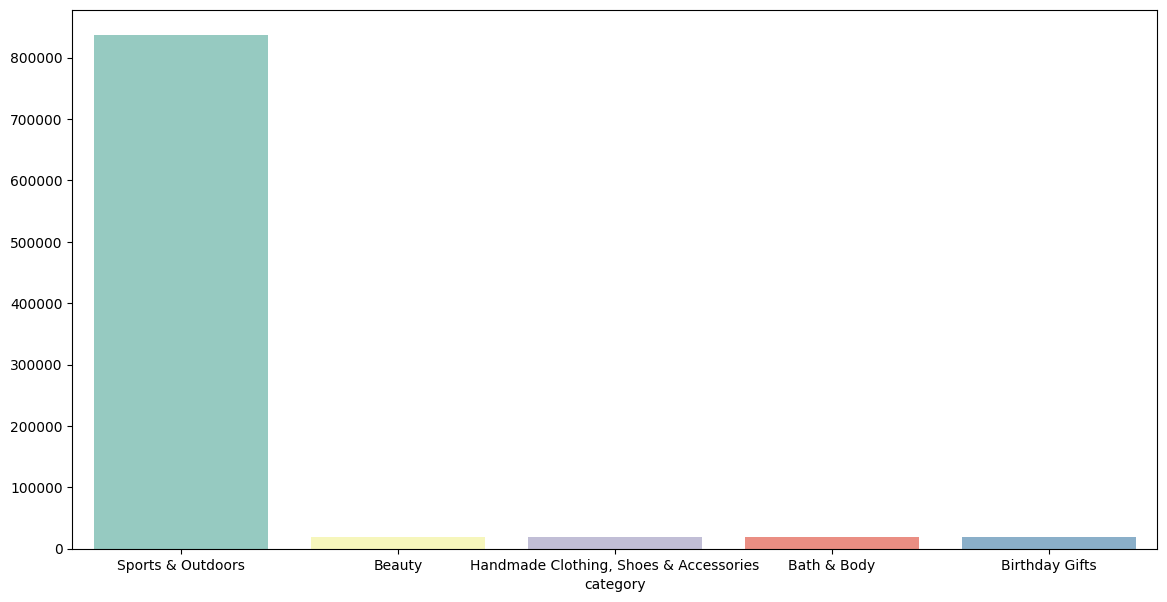

In [5]:
plt.figure(figsize=(14, 7))
sns.barplot(x=frequency_table.head().index, y=frequency_table.head().values, palette="Set3", hue=frequency_table.head().index);

<Axes: ylabel='count'>

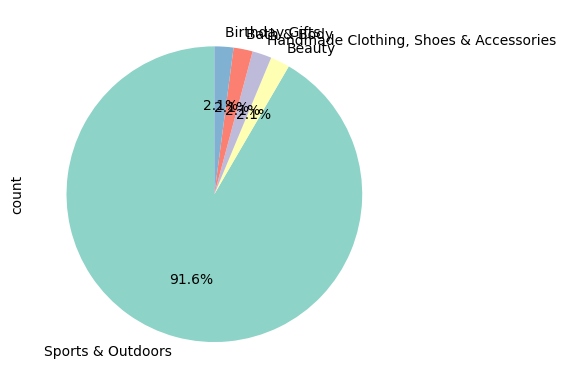

In [6]:
df['category'].value_counts().head().plot.pie(autopct='%1.1f%%', startangle=90, colors=sns.color_palette("Set3"))

---

## Part 2

In [7]:
mean_price = df['price'].mean()
median_price = df['price'].median()
mode_price = df['price'].mode()[0]  # mode() returns a Series

print(f"Mean: £{mean_price:.2f}, Median: £{median_price:.2f}, Mode: £{mode_price:.2f}")

Mean: £89.24, Median: £19.09, Mode: £9.99


In [8]:
variance = df['price'].var()
std_dev = df['price'].std()
price_range = df['price'].max() - df['price'].min()
iqr = df['price'].quantile(0.75) - df['price'].quantile(0.25)

print(f"Variance: {variance:.2f}")
print(f"Standard Deviation: {std_dev:.2f}")
print(f"Range: £{price_range:.2f}")
print(f"IQR: £{iqr:.2f}")

Variance: 119445.49
Standard Deviation: 345.61
Range: £100000.00
IQR: £36.00


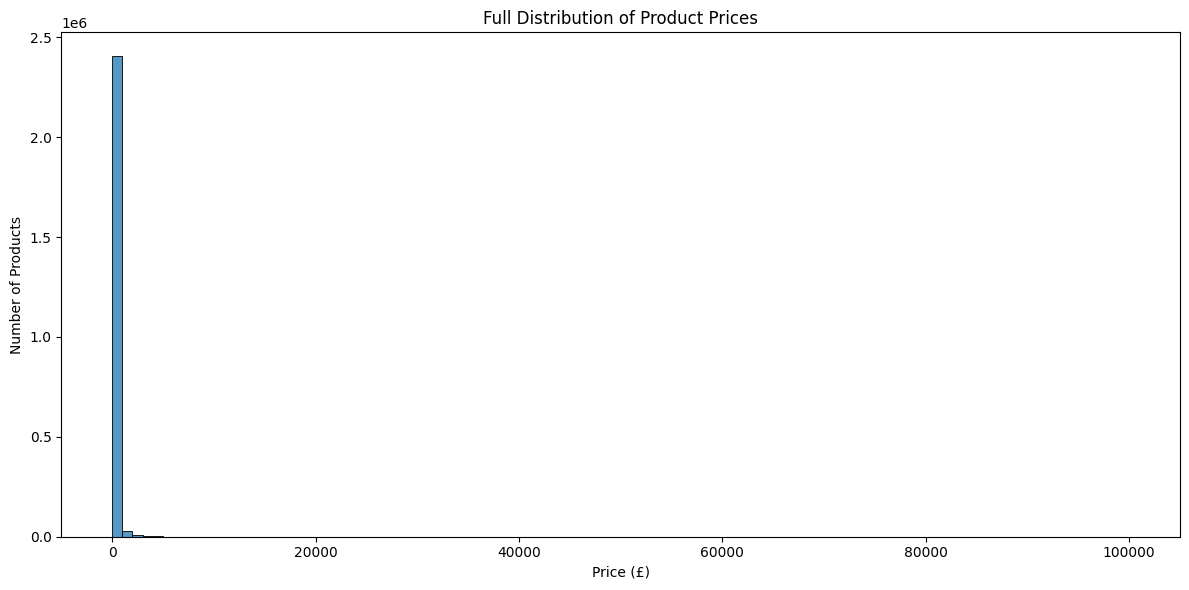

In [11]:
plt.figure(figsize=(12, 6))
sns.histplot(df['price'], bins=100)
plt.title("Full Distribution of Product Prices")
plt.xlabel("Price (£)")
plt.ylabel("Number of Products")
plt.tight_layout()
plt.show()

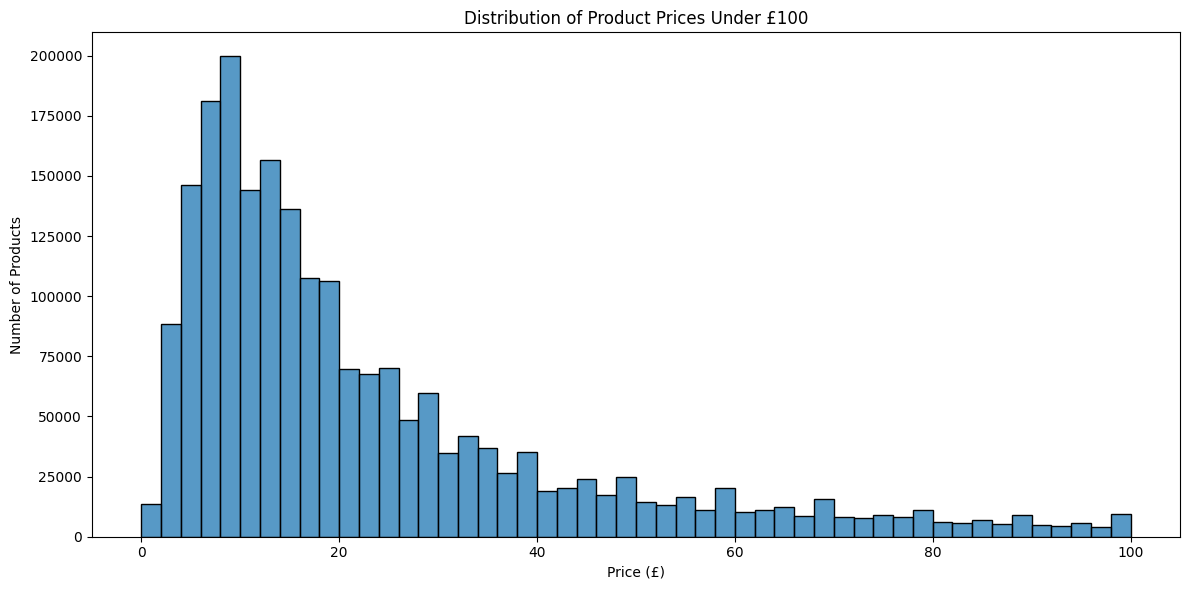

In [12]:
plt.figure(figsize=(12, 6))
sns.histplot(df[df['price'] < 100]['price'], bins=50)  # only prices under £100
plt.title("Distribution of Product Prices Under £100")
plt.xlabel("Price (£)")
plt.ylabel("Number of Products")
plt.tight_layout()
plt.show()

---

## Part 3

In [ ]:
# Disregard ratings that are 0 out of 5 stars, since half the dataframe is 0
# Thus we can assume that 0 means "not rated" rather than "rated 0 stars", so we'll exclude those from analysis

rated_df = df[df['stars'] > 0]

In [25]:
mean_rating = rated_df['stars'].mean()
median_rating = rated_df['stars'].median()
mode_rating = rated_df['stars'].mode()[0]

print(f"Mean: {mean_rating:.2f}, Median: {median_rating}, Mode: {mode_rating}")

Mean: 4.32, Median: 4.4, Mode: 4.5


In [26]:
variance = rated_df['stars'].var()
std_dev = rated_df['stars'].std()
iqr = rated_df['stars'].quantile(0.75) - df['stars'].quantile(0.25)

print(f"Variance: {variance:.2f}, Std Dev: {std_dev:.2f}, IQR: {iqr}")

Variance: 0.31, Std Dev: 0.56, IQR: 4.6


In [27]:
from scipy.stats import skew, kurtosis

skewness = skew(rated_df['stars'].dropna())
kurt = kurtosis(rated_df['stars'].dropna())

print(f"Skewness: {skewness:.2f}, Kurtosis: {kurt:.2f}")

Skewness: -2.38, Kurtosis: 9.78


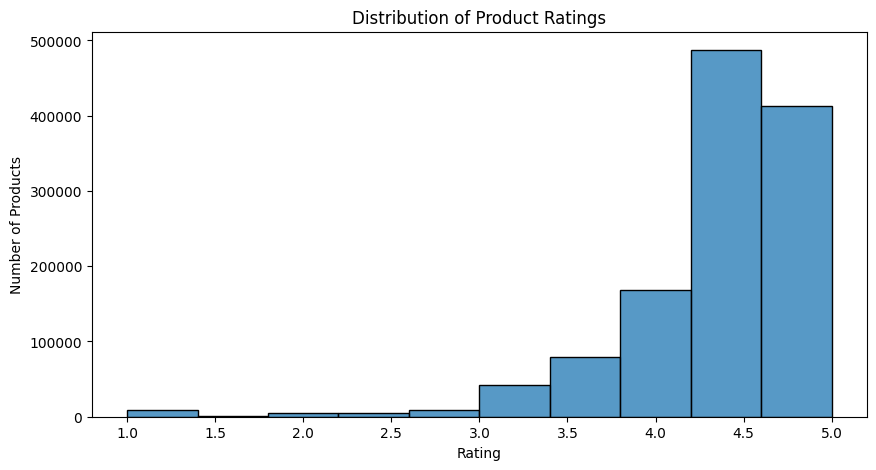

In [28]:
plt.figure(figsize=(10, 5))
sns.histplot(rated_df['stars'], bins=10, kde=False)
plt.title("Distribution of Product Ratings")
plt.xlabel("Rating")
plt.ylabel("Number of Products")
plt.show()